In Lecture 31 of MCS 320, we study differential equations, using the pendulum problem as the running example.

# 1. The Pendulum

A first model of the pendulum is a second order equation

$$
    L \frac{d^2}{d~\!t} \theta(t) = -g \theta(t),
$$

where $L$ is the length of the string and $g$ the gravitational constant,

subject to initial conditions

$$
    \theta(0) = \pi/10, \theta'(0) = 0.
$$

In [1]:
t = var('t')

In [2]:
theta = function('theta')(t)

In [3]:
g, L = var('g, L', domain='positive')

We have to assume that both ``g`` and ``L`` are positive, otherwise the symbolic solver will not work.

In [4]:
ode = L*diff(theta, t, 2) == - g*theta
show(ode)

L*diff(theta(t), t, t) == -g*theta(t)

In [5]:
sol = desolve(ode, theta, ivar=t)
sol

_K2*cos(sqrt(g)*t/sqrt(L)) + _K1*sin(sqrt(g)*t/sqrt(L))

As this is a second order equation, we have two families of solutions, with parameters ``_K1`` and ``_K2``.  When we specify the two initial conditions, we obtain a unique solution.

In [6]:
sol = desolve(ode, theta, ivar=t, ics=[0, pi/10, 0])
sol

1/10*pi*cos(sqrt(g)*t/sqrt(L))

Let us look at a particular instance for the symbolic parameters.

In [7]:
ft = sol(g=10, L=3)
ft

1/10*pi*cos(1/3*sqrt(10)*sqrt(3)*t)

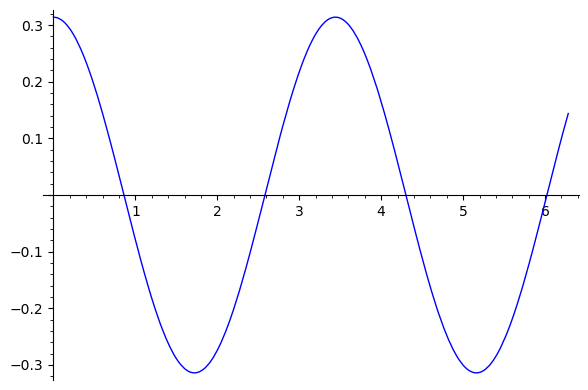

In [8]:
plot(ft, (t, 0, 2*pi))

Observe that the 0.3 corresponds to the $\pi/10$.

In [9]:
sin(RR(pi)/10)

0.309016994374947

In [10]:
RR(pi)/10

0.314159265358979

# 2. Solving with Laplace transforms

The short, direct way to solve this problem with Laplace transforms is as follows:

In [11]:
sol = desolve_laplace(ode, theta, ivar=t)
sol

(L^2*sin(sqrt(L*g)*t/L)*D[0](theta)(0)/sqrt(L*g) + L*cos(sqrt(L*g)*t/L)*theta(0))/L

In [12]:
init = {theta(t=0): pi/10, diff(theta,t).subs({t:0}): 0}
init

{theta(0): 1/10*pi, D[0](theta)(0): 0}

In [13]:
sol.subs(init)

1/10*pi*cos(sqrt(L*g)*t/L)

It is instructive to look at the long way to use Laplace transforms.

In [14]:
s = var('s')
Lode = ode.laplace('t', 's')
Lode

(s^2*laplace(theta(t), t, s) - s*theta(0) - D[0](theta)(0))*L == -g*laplace(theta(t), t, s)

In [15]:
T = var('T')
Teq = Lode.subs({laplace(theta,t,s): T})
Teq

(T*s^2 - s*theta(0) - D[0](theta)(0))*L == -T*g

In [16]:
sol = solve(Teq, T)
sol

[T == (L*s*theta(0) + L*D[0](theta)(0))/(L*s^2 + g)]

In [17]:
Ts = sol[0].rhs().subs(init)
Ts

1/10*pi*L*s/(L*s^2 + g)

In [18]:
ft = inverse_laplace(Ts, s, t)
ft

1/10*pi*cos(sqrt(L*g)*t/L)

# 3. Plotting the Slope Field

The slope field shows the velocities.

In [19]:
one = ft(g=10, L=1)
one

1/10*pi*cos(sqrt(10)*t)

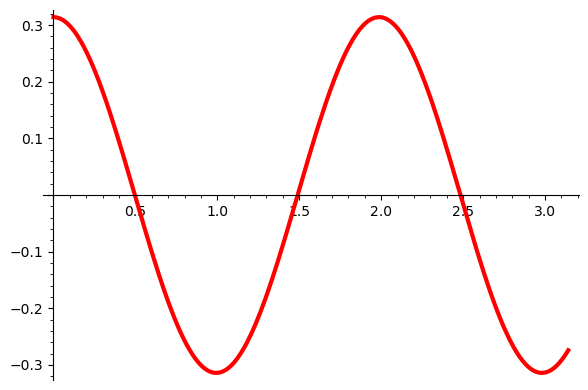

In [20]:
oneplot = plot(one, (t, 0, pi), color='red', thickness=3)
oneplot.show()

In [21]:
v = var('v')

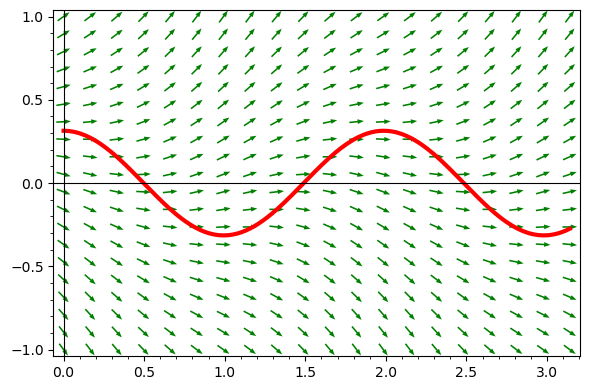

In [22]:
slopes = plot_slope_field(v-one, (t, 0, pi), (v, -1, 1),
                          headlength=4, headaxislength=4, color='green')
(oneplot+slopes).show()

In [23]:
dtone = diff(one, t)
dtone

-1/10*sqrt(10)*pi*sin(sqrt(10)*t)

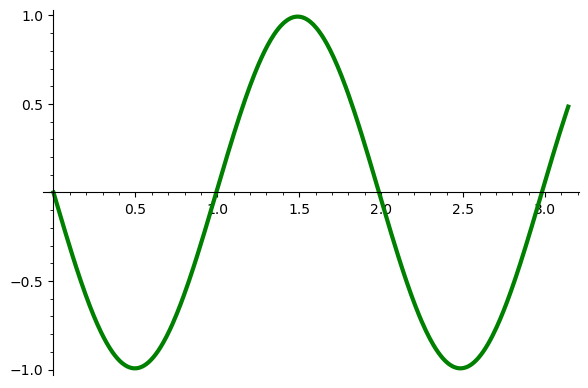

In [24]:
dtoneplot = plot(dtone, (t, 0, pi), color='green', thickness=3)
dtoneplot.show()

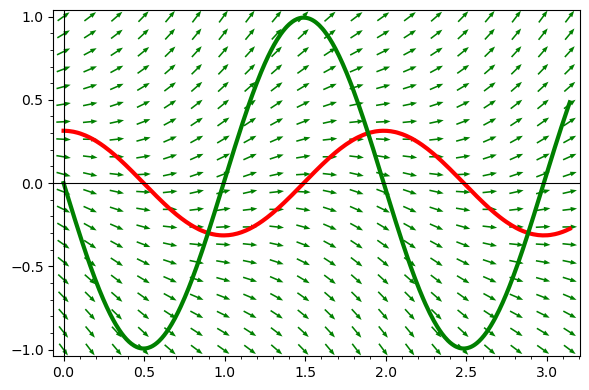

In [25]:
slopefield = oneplot+dtoneplot+slopes
slopefield.show()

# 4. The Pendulum with Damping

Set $g/L = 10$ and assume the damping constant to be 1.2.  The damping is proportional to the velocity.

$$
    \frac{d^2}{d~\!t^2} \theta(t) = - 1.2 \frac{d}{d~\!t} \theta(t) - 10 \sin(\theta(t)).
$$

To turn this is into a system of first order differential equations, we introduce

$$
    \frac{d}{d~\!t} \theta(t) = v(t)
$$

and obtain

$$
    \frac{d}{d~\!t} v(t) = - 1.2 v(t) - 10 \sin(\theta(t))
$$

In [26]:
theta, v = var('theta, v')
rhs = [v, -1.2*v - 10*sin(theta)]
rhs

[v, -1.20000000000000*v - 10*sin(theta)]

In [27]:
initc = [RR(pi)/10, 0.0]
initc

[0.314159265358979, 0.000000000000000]

In [28]:
endtime = 2*RR(pi)
step = 0.1
trange = srange(0, endtime, step)

In [29]:
sol = desolve_odeint(rhs,initc,trange,[theta,v])

In [30]:
angles = sol[:, 0]
pts = [(x, y) for (x, y) in zip(trange, angles)]

In [31]:
p = line(pts)

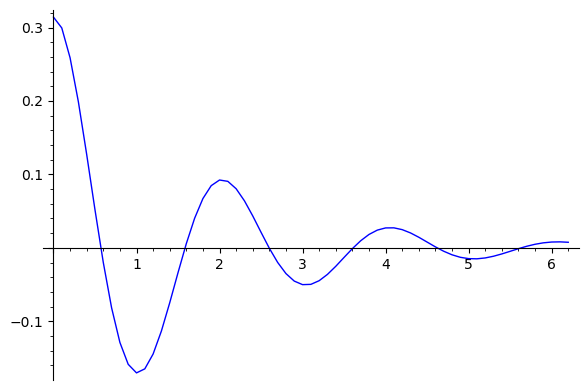

In [32]:
p.show()